# A calculator, a seed that only learned to call it, and PPO to convergence

`01` measured that on the raw Qwen3.5-0.8B the critic has nothing to read: the numbers are right 1%
of the time, and the return depends on whether the answer is right, which the model's state does
not know. This notebook gives the model a **calculator**, keeps the **prompt v2's**, and seeds the
policy with **one supervised pass that teaches only the three calls** -- no flag, no label, no
answer field. Then PPO with per-field credit, trained until it stops improving.

**The run converged.** `kl001-s0` stopped itself at step 700 after eight evaluations without a new
best; the best, step 500, was chosen on dev. On splits that chose nothing:

| | seed only | **PPO, step 500** | paired test (McNemar) |
| --- | --- | --- | --- |
| test, exact match | 0.005 | **0.285** | 56 cases gained, 0 lost, p = 3e-17 |
| test, cause | 0.290 | **0.825** | 113 gained, 6 lost, p = 1e-26 |
| test, flags / action | 0.598 / 0.140 | **0.902 / 0.605** | |
| holdout_shift, exact match | 0.020 | **0.400** | 19 gained, 0 lost, p = 4e-6 |

The arithmetic is the calculator's and the seed's: numeric is 1.000 before PPO and after. Everything
else in that table is PPO's. The critic got ahead of the position-only clock by steps 50-74 and was
ahead on 24 or 25 of every 25 steps from step 100 to the end, by +0.02 to +0.03. Train and dev
agree (reward 0.900 and 0.907), so it is not overfitting.

**What is left is one cell of the decision table.** Every true `colloidal_fouling` case in test --
29 of 29 -- is answered `scaling`, with the stage and the flags written correctly. The two causes
share their flags and differ only by stage, and the policy reads stage everywhere else in the table
but not there. The other six causes are right on 165 of 171 test cases.

In [1]:
import importlib.util, json, random, statistics as st, sys
from collections import deque
from pathlib import Path

import torch

HERE = Path.cwd() if (Path.cwd() / "02_tool_seed_ppo.py").exists() else Path("experiments/notebooks/smoke_test35")
# This notebook's own module; the file name starts with a digit, so it is loaded by path.
spec = importlib.util.spec_from_file_location("tool02", HERE / "02_tool_seed_ppo.py")
tool02 = importlib.util.module_from_spec(spec)
sys.modules["tool02"] = tool02
spec.loader.exec_module(tool02)
PREFIX, RUNS = tool02.PREFIX, tool02.RUNS
print(tool02.MODEL, "| prompt", tool02.PROMPT_VERSION, "+ the calculator's declaration")

Qwen/Qwen3.5-0.8B | prompt v2 + the calculator's declaration


## The prompt, the calculator and the episode layout

The prompt is `build_messages(record, "v2")`; the only addition is the tool declaration the chat
template writes when a tool is offered, printed below in full. The calculator is described
generically -- no example expression that could hint at the task's formulas -- and nothing tells
the model to use it.

Qwen3.5 calls tools in XML (`<tool_call><function=calculator><parameter=expression>...`) and gets
the replies back in one user turn of `<tool_response>` blocks. An episode is built by concatenating
tokens -- the prompt, the policy's turn up to its `<|im_end|>`, the tool's turn and the next assistant
header, the policy's next turn -- and that is what the chat template renders for the same
conversation, token for token. The three gold expressions reproduce the answer key on all 2,550
numbers of the four splits.

In [2]:
from transformers import AutoTokenizer
from task.prompt import SYSTEM_PROMPTS, build_user_prompt

tok = AutoTokenizer.from_pretrained(tool02.MODEL, padding_side="left")

# 1. The prompt is v2's two messages, plus the tools block the template writes.
case = tool02.load_cases("dev")[0]
prompt = tool02.render_tool_prompt(tok, case["record"])
system, user = SYSTEM_PROMPTS["v2"], build_user_prompt(case["record"], "v2")
assert system in prompt and user in prompt
tools_block = prompt[: prompt.index(system)]
print("v2's system and user turns appear verbatim; before them, the template adds:\n")
print(tools_block)

# 2. The gold expressions reproduce the answer key on every case of every split.
n = hit = 0
for split in ("train", "dev", "test", "holdout_shift"):
    for c in tool02.load_cases(split):
        for k, e in tool02.gold_expressions(c["record"]).items():
            n += 1
            hit += float(tool02.calculate(e)) == c["answer"][k]
print(f"gold expressions reproduce the key exactly: {hit}/{n}")

# 3. An episode built by concatenating tokens is what the template renders for the same conversation.
rec = case["record"]
exprs = list(tool02.gold_expressions(rec).values())
results = [tool02.calculate(e) for e in exprs]
conversation = tool02.build_messages(rec, "v2") + [
    {"role": "assistant", "content": "", "tool_calls": [
        {"type": "function", "function": {"name": "calculator", "arguments": {"expression": e}}} for e in exprs]},
] + [{"role": "tool", "content": r} for r in results]
rendered = tok.apply_chat_template(conversation, tools=[tool02.CALCULATOR_TOOL], tokenize=False,
                                   add_generation_prompt=True, enable_thinking=False)
im_end = tok.convert_tokens_to_ids("<|im_end|>")
built = (tok(prompt, add_special_tokens=False).input_ids
         + tok(tool02.tool_call_target(rec), add_special_tokens=False).input_ids + [im_end]
         + tok(tool02.tool_response_text(results, tool02.generation_prefix(tok)), add_special_tokens=False).input_ids)
print("concatenated episode == template rendering, token for token:", built == tok(rendered, add_special_tokens=False).input_ids)

/home/bayan/MembraneClaw/experiments/membrane_grpo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


v2's system and user turns appear verbatim; before them, the template adds:

<|im_start|>system
# Tools

You have access to the following functions:

<tools>
{"type": "function", "function": {"name": "calculator", "description": "Evaluate an arithmetic expression and return the result. Supports + - * / ** and parentheses, plus round(x, n) and abs(x).", "parameters": {"type": "object", "properties": {"expression": {"type": "string", "description": "the arithmetic expression"}}, "required": ["expression"]}}}
</tools>

If you choose to call a function ONLY reply in the following format with NO suffix:

<tool_call>
<function=example_function_name>
<parameter=example_parameter_1>
value_1
</parameter>
<parameter=example_parameter_2>
This is the value for the second parameter
that can span
multiple lines
</parameter>
</function>
</tool_call>

<IMPORTANT>
Reminder:
- Function calls MUST follow the specified format: an inner <function=...></function> block must be nested within <tool_call></too

## The seed

**The raw model with a calculator scores 0.** Offered a tool, it either reasons in prose until the
640-token budget runs out (68% of dev), or calls the calculator and then never writes an answer.

**A seed on the calls alone learns the calls and nothing else.** One supervised pass over the 400
training cases, the loss on the three gold calls and the `<|im_end|>` that hands them to the tool:
599 of 600 held-out first calls are exactly the gold expression. But its second turn calls again
instead of answering (4.9 calls per episode, 1% answered) -- the second assistant header looks like
the first, and the first was only ever followed by a call.

**One more token fixes it**: the answer turn's first token, the `{` that opens the JSON, also carries
a label, with the calculator's replies in context. The token is the same on every case, so it says
nothing about any answer; everything after it is the model's. The anchored seed calls three times,
answers every time, and gets numeric 1.000 -- and flags 0.610, cause 0.285, exact match 0.025, which
is where PPO starts. Most of its answers write the cause into `stage`, so only 10% pass the schema.
Epoch 3 is the seed.

In [3]:
def overall(path):
    return json.loads(Path(path).read_text())["overall"]

KEYS = ["normalized_flow_change_pct", "salt_passage_change_pct", "dp_change_pct"]
dev = {c["id"]: c for c in tool02.load_cases("dev")}

def first_calls(path):
    # the first three calls of each episode, against the gold expressions and the key
    same = right = 0
    rows = [json.loads(l) for l in Path(path).with_suffix(".episodes.jsonl").read_text().splitlines()]
    for r in rows:
        gold = tool02.gold_expressions(dev[r["id"]]["record"])
        for k, call, res in zip(KEYS, r["calls"][:3], r["results"][:3]):
            same += call.get("expression") == gold[k]
            try:
                right += abs(float(res) - dev[r["id"]]["answer"][k]) <= 0.5
            except ValueError:
                pass
    return same, right, 3 * len(rows)

rows = [("raw model + calculator", RUNS / "raw-calculator-dev.json")]
rows += [(f"calls only, epoch {e}", RUNS / f"tool-seed/epoch{e}-dev.json") for e in (1, 2, 3)]
rows += [(f"calls + answer open, epoch {e}", RUNS / f"tool-seed-anchor/epoch{e}-dev.json") for e in (1, 2, 3)]
print("dev, greedy, 200 cases\n")
print(f"  {'':30} {'first 3 calls = gold':>21} {'calls/ep':>9} {'errors':>7} {'answered':>9} "
      f"{'reward':>7} {'numeric':>8} {'flags':>6} {'cause':>6} {'EM':>6}")
for name, path in rows:
    o = overall(path)
    same, right, n = first_calls(path)
    print(f"  {name:30} {same:>13}/{n:<7} {o['tool_calls_mean']:>9.2f} {o['tool_error_rate']:>7.3f} "
          f"{o['validity_gate']:>9.2f} {o['reward']:>7.3f} {o['numeric_acc']:>8.3f} {o['flags_acc']:>6.3f} "
          f"{o['cause_acc']:>6.3f} {o['exact_match']:>6.3f}")

dev, greedy, 200 cases

                                  first 3 calls = gold  calls/ep  errors  answered  reward  numeric  flags  cause     EM
  raw model + calculator                     0/600          1.31   0.000      0.00   0.000    0.000  0.000  0.000  0.000
  calls only, epoch 1                      599/600          4.82   0.129      0.02   0.000    0.000  0.000  0.000  0.000
  calls only, epoch 2                      599/600          4.93   0.148      0.01   0.000    0.000  0.000  0.000  0.000
  calls only, epoch 3                      599/600          4.88   0.166      0.01   0.000    0.000  0.000  0.000  0.000
  calls + answer open, epoch 1             599/600          3.00   0.000      1.00   0.532    0.998  0.608  0.270  0.025
  calls + answer open, epoch 2             600/600          3.00   0.000      1.00   0.535    1.000  0.607  0.285  0.020
  calls + answer open, epoch 3             600/600          3.00   0.000      1.00   0.540    1.000  0.610  0.285  0.025


Two things that decide whether this is fair. **No record is shared between the splits**, so the seed
never saw a case it is later scored on. And **the only supervised token outside the calls is the
same token on every case.**

In [4]:
import itertools
from task.schema import _json_object_spans  # noqa: F401  (the scorer's own brace scanner, used below)

splits = {s: tool02.load_cases(s) for s in ("train", "dev", "test", "holdout_shift")}
records = {s: {json.dumps(c["record"], sort_keys=True) for c in cs} for s, cs in splits.items()}
for a, b in itertools.combinations(splits, 2):
    print(f"  {a:>13} and {b:<13} share {len(records[a] & records[b])} records")
opens = {tuple(tool02.seed_example(c, tok, anchor_open=True)[1][0, -1:].tolist()) for c in splits["train"]}
print(f"\n  the answer-open label over all {len(splits['train'])} seed examples: {len(opens)} distinct token(s),"
      f" {[tok.decode(list(t)) for t in opens]}")

          train and dev           share 0 records
          train and test          share 0 records
          train and holdout_shift share 0 records
            dev and test          share 0 records
            dev and holdout_shift share 0 records
           test and holdout_shift share 0 records



  the answer-open label over all 400 seed examples: 1 distinct token(s), ['{']


## Tuning the critic on the seed

The same two instruments as `01`, on 320 of the seed's own episodes sampled as a PPO step samples
them. **This time there is something to read.** Held out by prompt, every hidden layer adds
+0.011 to +0.015 over position; on the raw model every layer made it worse. It is a small margin,
and it is what the 1.7B series' critics had at the start of their runs.

Online, the step size the raw model preferred is now too slow; |dV| = 0.2 is the best on every
layer. The critic reads `hidden_states[23]` (the best ridge margin) with `lr = 0.2 / ||h||_1`
= 9.19e-4, starting from 0.4344, the mean return over the seed's tokens.

In [5]:
SEED = "02_tool_seed_ppo_runs/tool-seed-anchor/epoch3"
PROBE_CACHE = HERE / f"{PREFIX}_probe_cache.pt"
PROBE = HERE / f"{PREFIX}_probe.json"
LAYERS = (24, 23, 21, 18, 12)   # indices into hidden_states; 24 is the final, normed one
N_BATCHES, BATCH = 40, 8

def collect_probe():
    # The seed's own episodes, sampled exactly as a PPO step samples them: 8 train
    # prompts, temperature 1.0, the calculator in the loop, the credit the actor is paid.
    torch.manual_seed(1)
    rng = random.Random(1)
    policy, ptok = tool02.load_policy(tool02.MODEL, 16, "cuda", HERE / SEED)
    policy.eval()
    cases = tool02.load_cases("train")
    batches = []
    for k in range(N_BATCHES):
        chunk = [rng.choice(cases) for _ in range(BATCH)]
        roll = tool02.tool_rollout(policy, ptok, chunk, max_new_tokens=640, temperature=1.0, weights=tool02.ABLATE)
        paid = tool02.dense_rewards(roll.completions, roll.policy_ids, roll.mask, roll.cases, tool02.ABLATE, ptok, 3.0)
        with torch.no_grad():
            hs = []
            for i in range(BATCH):
                o = policy(input_ids=roll.sequences[i:i + 1], attention_mask=roll.attention_mask[i:i + 1],
                           position_ids=tool02.padded_position_ids(roll.attention_mask[i:i + 1]),
                           logits_to_keep=1, output_hidden_states=True)
                hs.append(torch.stack([tool02.take(o.hidden_states[l][:, -(roll.span + 1):-1], roll.index[i:i + 1])[0]
                                       for l in LAYERS]))
            hs = torch.stack(hs, 1)                    # (layers, batch, policy tokens, hidden)
        sel = roll.mask > 0
        returns = paid.flip(-1).cumsum(-1).flip(-1) * roll.mask   # gamma = lam = 1
        batches.append({
            "hidden": hs[:, sel].cpu(), "returns": returns.cpu(), "mask": roll.mask.cpu(),
            "answer": roll.answer_mask.cpu(), "rewards": roll.rewards, "case_ids": [c["id"] for c in chunk],
            "numeric": tool02.sampled_numeric(roll.completions, roll.cases), **tool02.tool_stats(roll.episodes),
        })
        print(f"  batch {k + 1}/{N_BATCHES}", end="\r")
    del policy
    torch.cuda.empty_cache()
    torch.save(batches, PROBE_CACHE)
    return batches

batches = torch.load(PROBE_CACHE, weights_only=False) if PROBE_CACHE.exists() else collect_probe()
seqs = N_BATCHES * BATCH
print(f"the seed, {seqs} sampled episodes at temperature 1.0 on train")
print(f"  reward {st.mean(r for b in batches for r in b['rewards']):.4f}   numeric {st.mean(b['numeric'] for b in batches):.3f}"
      f"   calls/ep {st.mean(b['tool_calls_mean'] for b in batches):.2f}   tool errors {st.mean(b['tool_error_rate'] for b in batches):.3f}"
      f"   truncated {st.mean(b['truncated_rate'] for b in batches):.3f}")

the seed, 320 sampled episodes at temperature 1.0 on train
  reward 0.5168   numeric 0.997   calls/ep 3.00   tool errors 0.000   truncated 0.000


In [6]:
# Is there anything in the seed's states to read? A ridge fit, held out by prompt --
# the check that said "nothing" on the raw model in 01.
def ridge_bound(li):
    G, P, H, C = [], [], [], []
    for b in batches:
        m = b["mask"] > 0
        L = m.shape[1]
        rel = (torch.arange(L).unsqueeze(0) / m.sum(-1, keepdim=True).clamp(min=1) * 20).floor().clamp(max=19).long()
        G.append(b["returns"][m]); P.append(rel[m]); H.append(b["hidden"][li].float())
        C += [cid for i, cid in enumerate(b["case_ids"]) for _ in range(int(m[i].sum()))]
    G, P, H = torch.cat(G).cuda(), torch.cat(P).cuda(), torch.cat(H).cuda()
    ids = sorted(set(C))
    fold = torch.tensor([ids.index(c) for c in C]) % 5
    onehot = torch.nn.functional.one_hot(P, 20).float()

    def cv(X, lam):
        pred = torch.zeros_like(G)
        for f in range(5):
            tr, te = (fold != f).cuda(), (fold == f).cuda()
            mu, sd = X[tr].mean(0), X[tr].std(0).clamp(min=1e-6)
            Z, ym = (X[tr] - mu) / sd, G[tr].mean()
            w = torch.linalg.solve(Z.T @ Z + lam * torch.eye(Z.shape[1], device="cuda"), Z.T @ (G[tr] - ym))
            pred[te] = ((X[te] - mu) / sd) @ w + ym
        return 1 - float(((G - pred) ** 2).mean() / G.var(unbiased=False))

    pos = cv(onehot, 1.0)
    best = max(cv(torch.cat([H, onehot], 1), lam) for lam in (1e1, 1e2, 1e3, 1e4, 1e5))
    return pos, best

def fit_online(li, lr, bias, epochs=8, window=25, clip=0.2):
    # The in-loop protocol replayed: score each batch before fitting on it, then 8
    # Adam steps over the last 25 batches.
    head = tool02.ValueHead(batches[0]["hidden"].shape[-1], bias).cuda()
    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=0.0)
    hist, rows = deque(maxlen=window), []
    for b in batches:
        h, mask, G = b["hidden"][li].cuda(), b["mask"].cuda(), b["returns"].cuda()
        with torch.no_grad():
            v = head(h)
        V = torch.zeros_like(G)
        V[mask > 0] = v
        rows.append(tool02.critic_fit(V, G, mask))
        hist.append((h, v, G[mask > 0]))
        H, OV, R = (torch.cat([x[j] for x in hist]) for j in range(3))
        for _ in range(epochs):
            opt.zero_grad(set_to_none=True)
            loss, _ = tool02.value_loss(head(H), OV, R, clip_eps=clip)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            opt.step()
    return rows

def summary(rows, skip=10):
    rows = [r for r in rows[skip:] if r["value_ev"] is not None]
    res = [r["value_ev"] - r["value_ev_position"] for r in rows]
    return {"ev": st.median(r["value_ev"] for r in rows), "clock": st.median(r["value_ev_position"] for r in rows),
            "residual": st.median(res), "ahead": sum(x > 0 for x in res) / len(res)}

BIAS = round(float(torch.cat([b["returns"][b["mask"] > 0] for b in batches]).mean()), 4)
norm1 = {l: float(torch.cat([b["hidden"][i] for b in batches]).float().abs().sum(-1).median())
         for i, l in enumerate(LAYERS)}
DV = (0.02, 0.07, 0.2)

if PROBE.exists():
    probe = json.loads(PROBE.read_text())
    probe["norm1"] = {int(k): v for k, v in probe["norm1"].items()}
    probe["ridge"] = {int(k): v for k, v in probe["ridge"].items()}
else:
    probe = {"bias": BIAS, "norm1": norm1, "ridge": {}, "configs": []}
    for i, l in enumerate(LAYERS):
        probe["ridge"][l] = ridge_bound(i)
        for dv in DV:
            lr = dv / norm1[l]
            probe["configs"].append({"layer": l, "dv": dv, "lr": lr, **summary(fit_online(i, lr, BIAS))})
    PROBE.write_text(json.dumps(probe, indent=2) + "\n")

print(f"starting value (mean return over the policy's tokens): {probe['bias']:.4f}\n")
print("ridge, held out by prompt: explained variance of the return")
for l, (pos, best) in probe["ridge"].items():
    print(f"  layer {l:>2}: position {pos:+.4f}   position + hidden {best:+.4f}   hidden adds {best - pos:+.4f}")
print("\nonline, the in-loop protocol, batches 11-40 (median)")
print(f"  {'layer':>5} {'||h||_1':>8} {'|dV|':>5} {'lr':>9} | {'critic':>7} {'clock':>7} {'residual':>9} {'ahead':>6}")
for c in probe["configs"]:
    print(f"  {c['layer']:>5} {probe['norm1'][c['layer']]:>8.0f} {c['dv']:>5} {c['lr']:>9.2e} | "
          f"{c['ev']:>+7.3f} {c['clock']:>+7.3f} {c['residual']:>+9.4f} {c['ahead']:>6.0%}")

starting value (mean return over the policy's tokens): 0.4344

ridge, held out by prompt: explained variance of the return
  layer 24: position +0.4605   position + hidden +0.4728   hidden adds +0.0123
  layer 23: position +0.4605   position + hidden +0.4758   hidden adds +0.0152
  layer 21: position +0.4605   position + hidden +0.4713   hidden adds +0.0108
  layer 18: position +0.4605   position + hidden +0.4730   hidden adds +0.0125
  layer 12: position +0.4605   position + hidden +0.4735   hidden adds +0.0130

online, the in-loop protocol, batches 11-40 (median)
  layer  ||h||_1  |dV|        lr |  critic   clock  residual  ahead
     24     3513  0.02  5.69e-06 |  +0.512  +0.524   -0.0085    10%
     24     3513  0.07  1.99e-05 |  +0.529  +0.524   +0.0030    57%
     24     3513   0.2  5.69e-05 |  +0.531  +0.524   +0.0030    60%
     23      218  0.02  9.19e-05 |  +0.492  +0.524   -0.0248     0%
     23      218  0.07  3.22e-04 |  +0.525  +0.524   -0.0029    40%
     23      218   0

## The configuration, and where each setting came from

The run is the 13b configuration of the 1.7B series -- `ABLATE` weights, per-field credit with 3x for
a correct `flat`, gamma 1, lambda 0.95, 8 prompts x 1 sample, 4 PPO epochs, clip 0.2, lr 1e-5 --
with the critic above, plus seven settings. Each was added after training on this model broke in a
specific way, and each is there to stop that one thing:

| setting | what it stops | measured when it was missing |
| --- | --- | --- |
| **`<|im_end|>` is the only way to end a turn**: `<|endoftext|>` is removed from the policy's vocabulary (sampling, log-probs, entropy) | a second end token the harness cannot hand to the tool | P(`<|endoftext|>` after the third call) went 0.0000 -> 0.998 in four PPO steps; every episode then ended before the calculator ran |
| **25 critic-only steps** before the actor moves | a critic that starts at one constant, far above what is left to earn late in the answer | advantage on the answer's last token -0.40 at step 0; within 12 steps the opening quote of `action` fell to 0.825x its seed probability, and unquoted values stopped parsing |
| **the `<|im_end|>` that ends a turn is left out of the actor's loss** | a token with no alternative and no reward of its own, whose advantage is only the critic's difference across the tool boundary | that advantage was negative on 37 of 38 steps from step 35; P(hand-over) 1.0000 -> 0.0006 by step 75, and the tool stopped being called |
| **no entropy bonus** | a bonus that spreads probability off near-certain format tokens | with 0.005 on the answer turn, answer entropy 0.03 -> 0.108 and `stage` turned into prose; 5 of 8 answers unparseable by step 37 |
| **each field's credit goes to the first JSON object whose content is the graded one** | credit that moves later for free when the answer is written twice | the same 0.540 left 0.380 still to earn after the first `}` -- a +0.38 reason to write the answer again |
| **a turn ends where its first JSON object closes** | text after the answer, which earns nothing either way and so drifts | answers grew a `</think>`, a second copy, then prose, to the 640-token budget (8 of 8 truncated at step 130) |
| **KL penalty towards the seed, 0.01 per token in the reward** | slow drift at any structural token the critic is slightly wrong about | the closing `}` drew a small negative advantage on 38 of 40 steps (about -0.01) until the model stopped closing the object at all. At 0.02 the brace held but learning slowed (exact match 0.045 against 0.195 at step 75) and the critic gate stopped the run |

The seed makes the scaffolding of the answer -- quotes, braces, the hand-over -- near-certain, and
its content uncertain; so the KL term is expensive exactly where drift broke earlier runs, and cheap
on the flags and the cause, which is where PPO has to move.

In [7]:
RUN = HERE / f"{PREFIX}_runs" / "kl001-s0"
cfg = json.loads((RUN / "config.json").read_text())
keys = ["start_from", "weights", "flat_credit_scale", "gamma", "lam", "prompts_per_step", "inner_epochs", "clip_eps",
        "lr", "value_layer", "value_lr", "value_init_bias", "critic_epochs", "critic_window", "critic_warmup",
        "freeze_turn_ends", "entropy_coef", "stop_at_json", "kl_coef", "patience", "regress_margin", "critic_gate_from"]
print("kl001-s0, as launched by 02_tool_seed_ppo_run_kl001.sh\n")
for k in keys:
    print(f"  {k:18} {cfg[k]}")
print(f"\n  ending: {json.loads((RUN / 'ending.json').read_text())}")

kl001-s0, as launched by 02_tool_seed_ppo_run_kl001.sh

  start_from         02_tool_seed_ppo_runs/tool-seed-anchor/epoch3
  weights            ABLATE
  flat_credit_scale  3.0
  gamma              1.0
  lam                0.95
  prompts_per_step   8
  inner_epochs       4
  clip_eps           0.2
  lr                 1e-05
  value_layer        23
  value_lr           0.0009189867391542886
  value_init_bias    0.4344
  critic_epochs      8
  critic_window      25
  critic_warmup      25
  freeze_turn_ends   1
  entropy_coef       0.0
  stop_at_json       1
  kl_coef            0.01
  patience           8
  regress_margin     0.05
  critic_gate_from   40

  ending: {'stopped_at': 700, 'reason': 'converged: 8 evaluations without beating held-out reward 0.9072 (step 500)', 'best_step': 500, 'best_reward': 0.9072}


## The run

Held out on the 200 dev cases every 25 steps, greedy. Nothing moves during the warm-up (steps 0-25
are identical by construction). Flags lead -- 0.61 -> 0.81 by step 50 -- then the cause follows in a
jump between steps 100 and 125 (0.515 -> 0.730), as the policy spreads its answers over six of the
seven causes. From step 300 it sits on a plateau between 0.875 and 0.907 in held-out reward; every
evaluation from 500 to 700 is within 0.013 of the best.

Exact match peaked at **0.565 at step 175** and settled near 0.38. The checkpoint is chosen by
held-out reward, the criterion every run in these series uses, so step 500 was kept and the
step-175 adapter was overwritten; the higher exact match is recorded in `eval.jsonl` but its policy
is not on disk.

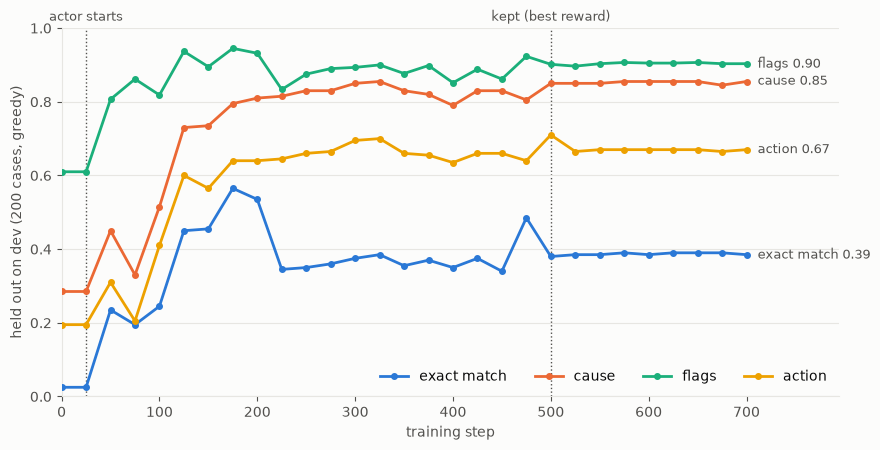

  step  reward     EM  cause  flags action numeric schema  causes said
     0  0.5396  0.025  0.285  0.610  0.195   1.000  0.105  4
    25  0.5396  0.025  0.285  0.610  0.195   1.000  0.105  4
    50  0.7358  0.235  0.450  0.807  0.310   1.000  1.000  4
    75  0.6966  0.195  0.330  0.862  0.205   1.000  1.000  5
   100  0.7679  0.245  0.515  0.818  0.410   0.998  1.000  5
   125  0.8603  0.450  0.730  0.937  0.600   0.998  1.000  6
   150  0.8516  0.455  0.735  0.895  0.565   0.998  1.000  7
   175  0.8876  0.565  0.795  0.945  0.640   0.998  1.000  6
   200  0.8897  0.535  0.810  0.932  0.640   0.998  1.000  6
   225  0.8799  0.345  0.815  0.833  0.645   0.998  1.000  6
   250  0.8909  0.350  0.830  0.875  0.660   0.998  1.000  6
   275  0.8941  0.360  0.830  0.890  0.665   1.000  1.000  6
   300  0.9015  0.375  0.850  0.893  0.695   0.995  0.995  7
   325  0.9067  0.385  0.855  0.900  0.700   1.000  1.000  6
   350  0.8917  0.355  0.830  0.877  0.660   1.000  1.000  6
   375  0.8911

In [8]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e7e6e2"
SERIES = {"exact_match": ("exact match", "#2a78d6"), "cause_acc": ("cause", "#eb6834"),
          "flags_acc": ("flags", "#1baf7a"), "action_acc": ("action", "#eda100")}
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
                     "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

evals = [json.loads(l) for l in (RUN / "eval.jsonl").read_text().splitlines()]
steps = [r["step"] for r in evals]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.grid(axis="y", color=GRID, linewidth=0.8)
for key, (label, color) in SERIES.items():
    ys = [r[key] for r in evals]
    ax.plot(steps, ys, color=color, linewidth=2, marker="o", markersize=4, label=label, zorder=3)
    ax.annotate(f"{label} {ys[-1]:.2f}", (steps[-1], ys[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", color=INK2, fontsize=9)
best = json.loads((RUN / "best.json").read_text())["step"]
for x, text in ((25, "actor starts"), (best, "kept (best reward)")):
    ax.axvline(x, color=INK2, linewidth=1, linestyle=":", zorder=1)
    ax.annotate(text, (x, 1.02), xycoords=("data", "axes fraction"), ha="center", color=INK2, fontsize=9)
ax.set_xlim(0, steps[-1] + 95)
ax.set_ylim(0, 1)
ax.set_xlabel("training step")
ax.set_ylabel("held out on dev (200 cases, greedy)")
ax.legend(loc="lower right", frameon=False, ncol=4)
fig.tight_layout()
fig.savefig(HERE / f"{PREFIX}_curves.png", dpi=150)
plt.show()

print(f"  {'step':>4} {'reward':>7} {'EM':>6} {'cause':>6} {'flags':>6} {'action':>6} {'numeric':>7} {'schema':>6}  causes said")
for r in evals:
    print(f"  {r['step']:>4} {r['reward']:>7.4f} {r['exact_match']:>6.3f} {r['cause_acc']:>6.3f} {r['flags_acc']:>6.3f} "
          f"{r['action_acc']:>6.3f} {r['numeric_acc']:>7.3f} {r['schema_ok']:>6.3f}  {len(r['predicted_cause_hist'])}")

## The critic, and the scaffolding

Left: the critic's explained variance minus the clock's, median over each 25-step window. It is
behind while the warm-up fits it and the policy starts moving, level by steps 50-74 (the gate
passed at +0.004), and ahead on 24 or 25 of every 25 steps from step 100 to the end, by +0.02 to
+0.03 -- the same margin the 1.7B series reached.

Right: the advantage on the answer's closing `}`, the token whose drift ended an earlier run. It is
still slightly negative on most windows -- the critic still overestimates what is left at the last
token -- but the KL penalty makes leaving the brace expensive, and **no answer failed to parse in
any sampled batch, and none was truncated**, over all 700 steps.

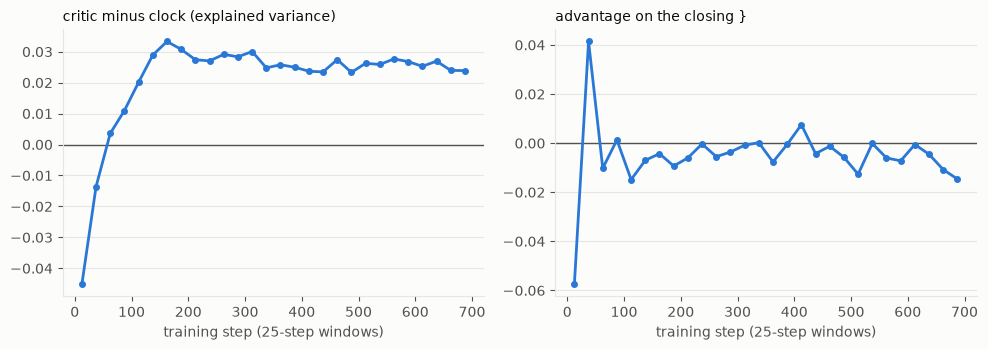

      steps critic-clock  ahead  adv at }  KL/answer token  unparsed truncated
    0-24         -0.0452   0/25   -0.0575           0.0000     0/40      0/40 
   25-49         -0.0136   3/25   +0.0414           0.0733     0/40      0/40 
   50-74         +0.0036  19/25   -0.0102           0.1148     0/40      0/40 
   75-99         +0.0110  23/25   +0.0013           0.1239     0/40      0/40 
  100-124        +0.0201  24/25   -0.0149           0.1420     0/40      0/40 
  125-149        +0.0289  25/25   -0.0070           0.1423     0/40      0/40 
  150-174        +0.0333  25/25   -0.0043           0.1468     0/40      0/40 
  175-199        +0.0307  25/25   -0.0093           0.1283     0/40      0/40 
  200-224        +0.0274  25/25   -0.0060           0.1451     0/40      0/40 
  225-249        +0.0270  25/25   -0.0003           0.1408     0/40      0/40 
  250-274        +0.0291  25/25   -0.0055           0.1440     0/40      0/40 
  275-299        +0.0283  24/25   -0.0036           

In [9]:
rows = [json.loads(l) for l in (RUN / "metrics.jsonl").read_text().splitlines()]
samples = [json.loads(l) for l in (RUN / "samples.jsonl").read_text().splitlines()]
W = 25
starts = list(range(0, len(rows) - W + 1, W))

def window(a, key_fn):
    vals = [key_fn(r) for r in rows[a:a + W]]
    return [v for v in vals if v is not None]

crit = [st.median(window(a, lambda r: None if r["value_ev"] is None or r["value_ev_position"] is None
                          else r["value_ev"] - r["value_ev_position"])) for a in starts]
brace = [st.mean(window(a, lambda r: r.get("adv_last_turn_end"))) for a in starts]
mids = [a + W / 2 for a in starts]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, ys, title in ((axes[0], crit, "critic minus clock (explained variance)"),
                      (axes[1], brace, "advantage on the closing }")):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.axhline(0, color=INK2, linewidth=1)
    ax.plot(mids, ys, color="#2a78d6", linewidth=2, marker="o", markersize=4, zorder=3)
    ax.set_title(title, color=INK, fontsize=10, loc="left")
    ax.set_xlabel("training step (25-step windows)")
fig.tight_layout()
fig.savefig(HERE / f"{PREFIX}_critic.png", dpi=150)
plt.show()

print(f"  {'steps':>9} {'critic-clock':>12} {'ahead':>6} {'adv at }':>9} {'KL/answer token':>16} {'unparsed':>9} {'truncated':>9}")
for a, c, b in zip(starts, crit, brace):
    res = window(a, lambda r: None if r["value_ev"] is None or r["value_ev_position"] is None
                 else r["value_ev"] - r["value_ev_position"])
    kl = st.mean(window(a, lambda r: r.get("kl_answer")))
    samp = [s for s in samples if a <= s["step"] < a + W]
    print(f"  {a:>3}-{a + W - 1:<5} {c:>+12.4f} {sum(x > 0 for x in res):>3}/{len(res):<2} {b:>+9.4f} {kl:>16.4f} "
          f"{sum(s['reward'] == 0 for s in samp):>5}/{len(samp):<3} {sum(s['truncated'] for s in samp):>5}/{len(samp):<3}")

## Held out, and what the seed alone scores

The checkpoint and the seed it started from, greedy, under the same turn protocol, on every split.
Test and holdout_shift chose nothing; dev chose the checkpoint, and the drop from dev to test in exact
match (0.380 -> 0.285) is what that selection bought. The paired tests compare the two policies on
the same cases.

**Train and dev score the same** (reward 0.900 and 0.907, cause 0.850 on both), so the gain is not
the policy memorising its 400 training records.

In [10]:
import math

def overall(path):
    return json.loads(Path(path).read_text())["overall"]

SEEDD = RUNS / "tool-seed-anchor"
table = [("PPO, step 500", "dev", RUN / "best.json"), ("PPO, step 500", "test", RUN / "best-test.json"),
         ("PPO, step 500", "holdout_shift", RUN / "best-holdout_shift.json"), ("PPO, step 500", "train", RUN / "best-train.json"),
         ("seed only", "dev", SEEDD / "epoch3-stopjson-dev.json"), ("seed only", "test", SEEDD / "epoch3-stopjson-test.json"),
         ("seed only", "holdout_shift", SEEDD / "epoch3-stopjson-holdout_shift.json")]
print(f"  {'':14} {'split':14} {'n':>4} {'reward':>7} {'EM':>6} {'cause':>6} {'flags':>6} {'action':>6} {'numeric':>7} {'schema':>6}")
for name, split, path in table:
    o = json.loads(Path(path).read_text())
    o = o.get("overall", o)
    print(f"  {name:14} {split:14} {o.get('n_cases', 200):>4} {o['reward']:>7.4f} {o['exact_match']:>6.3f} {o['cause_acc']:>6.3f} "
          f"{o['flags_acc']:>6.3f} {o['action_acc']:>6.3f} {o['numeric_acc']:>7.3f} {o['schema_ok']:>6.3f}")

def mcnemar(b, c):
    n, k = b + c, min(b, c)
    return min(1.0, 2 * sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n)

print("\n  paired, seed -> PPO on the same cases (exact two-sided McNemar)")
for split in ("test", "holdout_shift"):
    ppo = overall(RUN / f"best-{split}.json")["per_case"]
    seed = {r["id"]: r for r in overall(SEEDD / f"epoch3-stopjson-{split}.json")["per_case"]}
    for key, label in (("exact", "exact match"), ("cause", "cause")):
        gained = sum(r[key] and not seed[r["id"]][key] for r in ppo)
        lost = sum(seed[r["id"]][key] and not r[key] for r in ppo)
        print(f"    {split:14} {label:12} gained {gained:>3}  lost {lost:>2}  p = {mcnemar(gained, lost):.1e}")

                 split             n  reward     EM  cause  flags action numeric schema
  PPO, step 500  dev             200  0.9072  0.380  0.850  0.902  0.710   1.000  1.000
  PPO, step 500  test            200  0.8852  0.285  0.825  0.902  0.605   1.000  1.000
  PPO, step 500  holdout_shift    50  0.8996  0.400  0.820  0.913  0.700   1.000  1.000
  PPO, step 500  train           400  0.8996  0.335  0.850  0.900  0.662   0.999  1.000
  seed only      dev             200  0.5396  0.025  0.285  0.610  0.195   1.000  0.105
  seed only      test            200  0.5306  0.005  0.290  0.598  0.140   1.000  0.095
  seed only      holdout_shift    50  0.5654  0.020  0.320  0.620  0.260   1.000  0.160

  paired, seed -> PPO on the same cases (exact two-sided McNemar)
    test           exact match  gained  56  lost  0  p = 2.8e-17
    test           cause        gained 113  lost  6  p = 1.1e-26
    holdout_shift  exact match  gained  19  lost  0  p = 3.8e-06
    holdout_shift  cause        ga

## What is left: one cell of the decision table

Recall by true cause on test. Six causes are right on 165 of 171 cases. **`colloidal_fouling` is 0
of 29, and every one of them is answered `scaling`** -- with the stage written correctly on all 29
and all three flags right on 28.

The decision table says why this is one mistake and not a vocabulary gap. `colloidal_fouling` and
`scaling` share the flag pattern `(down, flat, up)` and differ only by stage: `lead` is colloidal
fouling, `tail` is scaling. The policy uses the stage to separate biofouling from scaling (23 of 29,
same situation, different flags), and does not use it for this row. The label is not dead in the
sense of `smoke_test/14` -- it is never *said* because the row that leads to it is read as scaling's.
That is where `03` starts.

In [11]:
import re
from task.decision_table import COVERED

import collections

cases = {c["id"]: c for c in splits["test"]}
right, total, colloidal = collections.Counter(), collections.Counter(), collections.Counter()
for line in (RUN / "best-test.episodes.jsonl").read_text().splitlines():
    e = json.loads(line)
    truth = cases[e["id"]]["answer"]["root_cause"]
    found = re.search(r'"root_cause"\s*:\s*"([a-z_]*)"', e["text"])
    said = found.group(1) if found else None
    total[truth] += 1
    right[truth] += said == truth
    if truth == "colloidal_fouling":
        colloidal[said] += 1
print("  test, recall by true cause")
for cause in sorted(total):
    print(f"    {cause:18} {right[cause]:>3}/{total[cause]}")
per_case = {r["id"]: r for r in overall(RUN / "best-test.json")["per_case"]}
col = [per_case[i] for i, c in cases.items() if c["answer"]["root_cause"] == "colloidal_fouling"]
print(f"\n  the {len(col)} colloidal_fouling cases: answered {dict(colloidal)}; stage right {sum(r['stage'] for r in col)}, "
      f"all three flags right {sum(r['flags_ok'] for r in col)}")
print("\n  the decision table's rows for flags (down, flat, up):")
for key, cause in COVERED.items():
    if key[:3] == ("down", "flat", "up"):
        print(f"    stage {key[3]:5} -> {cause}")

  test, recall by true cause
    biofouling          23/29
    colloidal_fouling    0/29
    compaction          28/28
    mechanical_leak     28/28
    organic_fouling     29/29
    oxidation_damage    28/28
    scaling             29/29

  the 29 colloidal_fouling cases: answered {'scaling': 29}; stage right 29, all three flags right 28

  the decision table's rows for flags (down, flat, up):
    stage tail  -> scaling
    stage lead  -> colloidal_fouling


## Summary

* A calculator and a seed that learns only to call it -- plus the answer's opening brace -- take the
  raw 0.8B from reward 0 to numeric 1.000 with nothing else supervised.
* On that seed the critic has something to read, and in the converged run it is ahead of the
  position-only clock from step 50 and by +0.02 to +0.03 from step 100 to the end.
* PPO then takes held-out exact match from 0.005 to 0.285 on test and 0.020 to 0.400 on
  holdout_shift, cause from 0.290 to 0.825 -- 56 and 113 cases gained against 0 and 6 lost -- with no
  gap between train and dev.
* It took seven settings to keep the answer's scaffolding intact under PPO on this model, and each
  one is tied to the failure it prevents. The general one is the KL penalty towards the seed.
* The remaining cause error is a single row: `(down, flat, up, lead)` -> `colloidal_fouling`, read as
  `scaling` on all 29 test cases.